# Milestone 3 — Cluster Profiles, Names, Risk Tiers

Build clinical profiles per cluster, compute ANOVA significance, assign clinically meaningful
names, and categorize Low/Medium/High risk. Persist `models/cluster_profiles.json` and
`data/processed/patients_clustered.csv`.

Uses the clinical core matrix (egfr, sc, hemo, bgr, multimorbidity, anemia_severity, cv_risk,
age, bp) — same as notebook 04.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data_loader import load_ckd
from src.preprocessing import clean_types, ClinicalImputer, encode_binary
from src.features import (
    compute_egfr, multimorbidity_score, compute_anemia_severity, compute_cv_risk,
)
from src.profiles import compute_cluster_profiles, name_clusters, assign_risk_tiers, persist_profiles

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures')
MODELS = Path('../models')
DATA = Path('../data/processed')


## 1. Rebuild the clinical core matrix + load models

In [2]:
raw = clean_types(load_ckd('../data/raw/kidney_disease.csv'))
imputer = ClinicalImputer().fit(raw)
raw = imputer.transform(raw)
raw = encode_binary(raw)
raw = compute_egfr(raw)
raw = multimorbidity_score(raw)
raw = compute_anemia_severity(raw)
raw = compute_cv_risk(raw)

with open(MODELS / 'core_features.json') as f:
    cfg = json.load(f)
CORE_FEATURES = cfg['core_features']

core_raw = raw[CORE_FEATURES].copy()
core_scaler = joblib.load(MODELS / 'core_scaler.pkl')
X = pd.DataFrame(core_scaler.transform(core_raw), columns=CORE_FEATURES)

km = joblib.load(MODELS / 'kmeans.pkl')
gmm = joblib.load(MODELS / 'gmm.pkl')
labels = km.predict(X)
proba = gmm.predict_proba(X)
confidence = proba.max(axis=1)
print('Cluster sizes:', dict(zip(*np.unique(labels, return_counts=True))))


Cluster sizes: {0: 120, 1: 208, 2: 72}


## 2. Profiles + delta vs population (using raw clinical values)

In [3]:
# Use unscaled clinical values for interpretable means
profiles = compute_cluster_profiles(core_raw, labels)
print('Per-cluster sizes + key clinical means:')
for cid, p in profiles.items():
    fm = p['feature_means']
    print(f"  cluster {cid} (n={p['size']}): egfr={fm['egfr']:.1f}, "
          f"sc={fm['sc']:.2f}, hemo={fm['hemo']:.1f}, multimorb={fm['multimorbidity']:.2f}, "
          f"anemia_sev={fm['anemia_severity']:.2f}, cv_risk={fm['cv_risk']:.2f}")


Per-cluster sizes + key clinical means:
  cluster 0 (n=120): egfr=28.7, sc=3.12, hemo=11.7, multimorb=1.88, anemia_sev=0.62, cv_risk=1.98
  cluster 1 (n=208): egfr=80.1, sc=1.02, hemo=14.5, multimorb=0.12, anemia_sev=0.12, cv_risk=0.14
  cluster 2 (n=72): egfr=12.3, sc=8.44, hemo=8.5, multimorb=2.82, anemia_sev=2.07, cv_risk=2.10


## 3. ANOVA across clusters

In [4]:
anova_results = {}
for col in core_raw.columns:
    valid_groups = [core_raw.loc[labels == cid, col].values
                    for cid in sorted(set(labels))
                    if (labels == cid).sum() >= 2]
    if len(valid_groups) >= 2:
        f, pv = stats.f_oneway(*valid_groups)
        anova_results[col] = {'F': float(f), 'p': float(pv)}
anova_df = pd.DataFrame(anova_results).T.sort_values('p')
alpha = 0.05 / len(anova_df) if len(anova_df) else 0.05
print(f'Bonferroni-corrected alpha: {alpha:.4f}')
print('ANOVA across clusters (sorted by p):')
print(anova_df)


Bonferroni-corrected alpha: 0.0056
ANOVA across clusters (sorted by p):
                          F              p
anemia_severity  485.941229  1.955389e-107
multimorbidity   404.659326   1.547747e-96
hemo             380.676656   4.869319e-93
cv_risk          325.362430   2.191981e-84
egfr             313.515446   2.054819e-82
bgr               73.101366   9.331883e-28
age               71.813787   2.396759e-27
sc                60.106724   1.572022e-23
bp                26.228874   2.000666e-11


## 4. Names + risk tiers

In [5]:
named = name_clusters(profiles)
tiered = assign_risk_tiers(named)

for cid in tiered:
    mask = labels == cid
    tiered[cid]['gmm_proba_mean'] = float(confidence[mask].mean())

print('Final cluster summary:')
for cid, p in tiered.items():
    print(f"  {cid}: {p['name']:35s} | risk={p['risk_tier']:6s} | "
          f"n={p['size']:3d} | conf={p['gmm_proba_mean']:.3f}")


Final cluster summary:
  0: Moderate Renal Risk                 | risk=Medium | n=120 | conf=0.996
  1: Stable / Low-Risk                   | risk=Low    | n=208 | conf=0.990
  2: Severe Renal Impairment             | risk=High   | n= 72 | conf=0.992


## 5. Radar chart per cluster

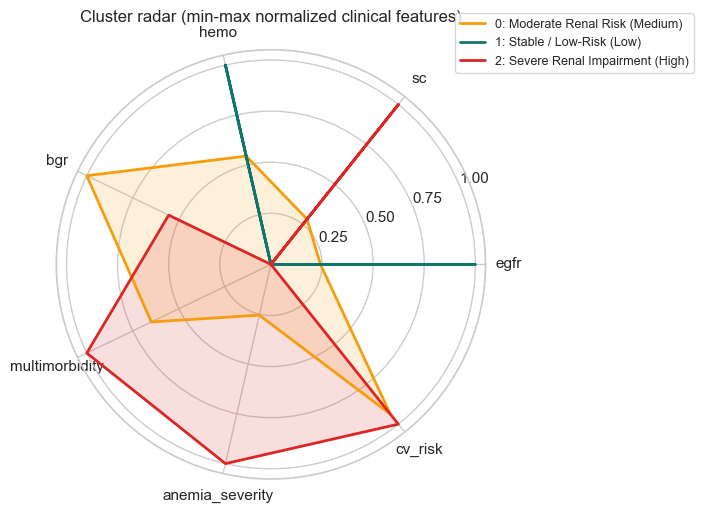

In [6]:
features_for_radar = ['egfr', 'sc', 'hemo', 'bgr', 'multimorbidity', 'anemia_severity', 'cv_risk']
mat = np.array([[tiered[cid]['feature_means'].get(f, 0.0) for f in features_for_radar]
                for cid in sorted(tiered)])
mn, mx = mat.min(0), mat.max(0)
norm = np.where(mx > mn, (mat - mn) / (mx - mn + 1e-9), 0.5)

theta = np.linspace(0, 2 * np.pi, len(features_for_radar), endpoint=False)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
risk_colors = {'Low': '#0F766E', 'Medium': '#F59E0B', 'High': '#DC2626'}
for i, cid in enumerate(sorted(tiered)):
    vals = np.concatenate([norm[i], [norm[i, 0]]])
    angles = np.concatenate([theta, [theta[0]]])
    color = risk_colors.get(tiered[cid]['risk_tier'], '#6B7280')
    ax.plot(angles, vals, label=f"{cid}: {tiered[cid]['name']} ({tiered[cid]['risk_tier']})", color=color, linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=color)
ax.set_xticks(theta); ax.set_xticklabels(features_for_radar)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title('Cluster radar (min-max normalized clinical features)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(FIGDIR / 'cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Persist artifacts

In [7]:
persist_profiles(tiered, MODELS / 'cluster_profiles.json')

# Build patients_clustered.csv: M2 features + 2D projections + cluster info
df_features = pd.read_csv(DATA / 'patients_features.csv')
out = df_features.copy()
out['cluster_id'] = labels
out['gmm_confidence'] = confidence
out['cluster_name'] = pd.Series(labels).map(lambda c: tiered[c]['name'])
out['risk_tier'] = pd.Series(labels).map(lambda c: tiered[c]['risk_tier'])
# Append raw clinical values used for profiling (so dashboard can show them)
for col in CORE_FEATURES:
    out[f'raw_{col}'] = core_raw[col].values

out.to_csv(DATA / 'patients_clustered.csv', index=False)
print('Saved cluster_profiles.json + patients_clustered.csv:', out.shape)
print('Risk tier distribution:')
print(out['risk_tier'].value_counts())


Saved cluster_profiles.json + patients_clustered.csv: (400, 53)
Risk tier distribution:
risk_tier
Low       208
Medium    120
High       72
Name: count, dtype: int64
